In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df2=pd.read_csv('Income_credit_score.csv')
data = pd.read_csv('Customer.csv')
#loan=pd.read_csv('Loan_updated.csv')
#dti=pd.read_csv('DTI.csv')
df=pd.read_csv('Loan_risk.csv')
df1=pd.read_csv('credit_risk_branch.csv')


In [35]:
df_clust_H = df[['Customer_ID','Clusters']].drop_duplicates('Customer_ID')
df_clust = df[['Customer_ID','Clusters']]


df_clust_H.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3043 entries, 0 to 4996
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Customer_ID  3043 non-null   object
 1   Clusters     3043 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 71.3+ KB


In [49]:
data['City']=data['City'].str.strip()
#data.head()
df_city=pd.merge(df,data[['Customer_ID','Income','City']],on=['Customer_ID','Income'],how='left')
df1.head()

,Customer_ID,Credit_score,Branch,Risk_segment
0,CUST1000,781,TRIVANDRUM,Low risk
1,CUST1001,660,CHENNAI,Medium risk
2,CUST1003,824,TRIVANDRUM,Low risk
3,CUST1004,558,TRIVANDRUM,High Risk
4,CUST1005,439,CALICUT,High Risk


In [10]:
dti.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3043 entries, 0 to 3042
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         3043 non-null   object 
 1   Income              3043 non-null   int64  
 2   Monthly_income      3043 non-null   float64
 3   Total_loan_amount   3043 non-null   int64  
 4   Total_loan_payment  3043 non-null   float64
 5   DTI                 3043 non-null   float64
 6   LTI                 3043 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 166.5+ KB


In [9]:
#Correlation 

print(dti[['Income','DTI','LTI']].corr())

          Income       DTI       LTI
Income  1.000000 -0.375108 -0.468097
DTI    -0.375108  1.000000  0.766608
LTI    -0.468097  0.766608  1.000000


  Income_bracket         DTI        LTI
0         <1000k  653.663322  18.355407
1    1000k-2000k  203.007773   4.998151
2    2000k-3000k  121.261785   3.206094
3    3000k-4000k   91.520082   2.365431
4    4000k-5000k   85.459397   2.056185


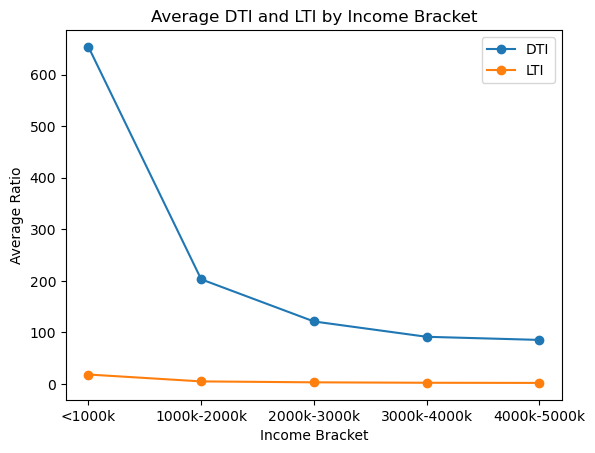

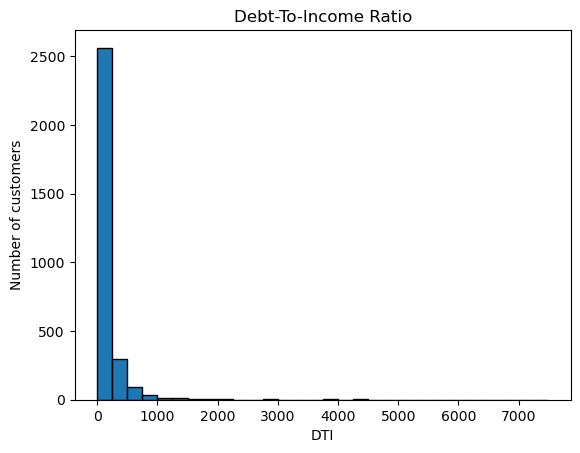

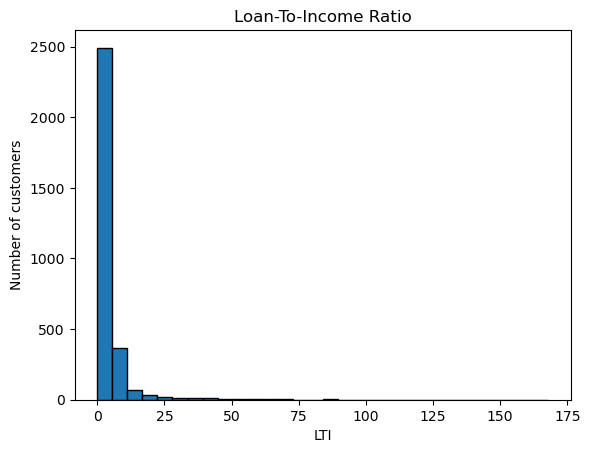

C:\Users\Admin\AppData\Local\Temp\ipykernel_13104\3180429623.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([dti['DTI'],dti['LTI']],labels=['DTI','LTI'])


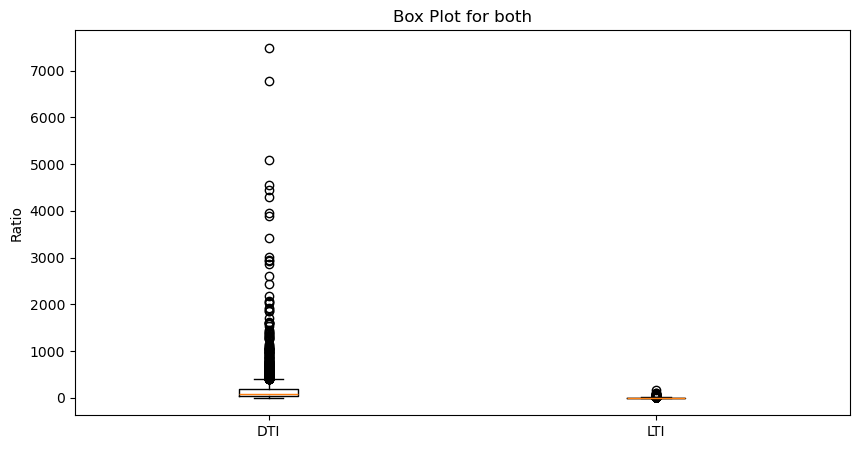

In [23]:
#customer income bracket and visualization

bins=[100000,1000000,2000000,3000000,4000000,5000000]
labels=['<1000k','1000k-2000k','2000k-3000k','3000k-4000k','4000k-5000k']

dti['Income_bracket']=pd.cut(dti['Income'],bins=bins,labels=labels)

#average DTI and LTI per bracket

income_groups=dti.groupby('Income_bracket',observed=False)[['DTI','LTI']].mean().reset_index()

print(income_groups)


#VISUALISATION

plt.plot(income_groups['Income_bracket'],income_groups['DTI'],marker='o',label='DTI')
plt.plot(income_groups['Income_bracket'],income_groups['LTI'],marker='o',label='LTI')
plt.xlabel('Income Bracket')
plt.ylabel('Average Ratio')
plt.title('Average DTI and LTI by Income Bracket')
plt.legend()
plt.show()


#HISTOGRAM for DTI

plt.hist(dti['DTI'],bins=30,edgecolor='black')
plt.xlabel('DTI')
plt.ylabel('Number of customers')
plt.title('Debt-To-Income Ratio')
plt.show()

#HSTOGRAM for LTI
plt.hist(dti['LTI'],bins=30,edgecolor='black')
plt.xlabel('LTI')
plt.ylabel('Number of customers')
plt.title('Loan-To-Income Ratio')
plt.show()


#BOXPLOT for both

plt.figure(figsize=(10,5))
plt.boxplot([dti['DTI'],dti['LTI']],labels=['DTI','LTI'])
plt.ylabel('Ratio')
plt.title('Box Plot for both')
plt.show()

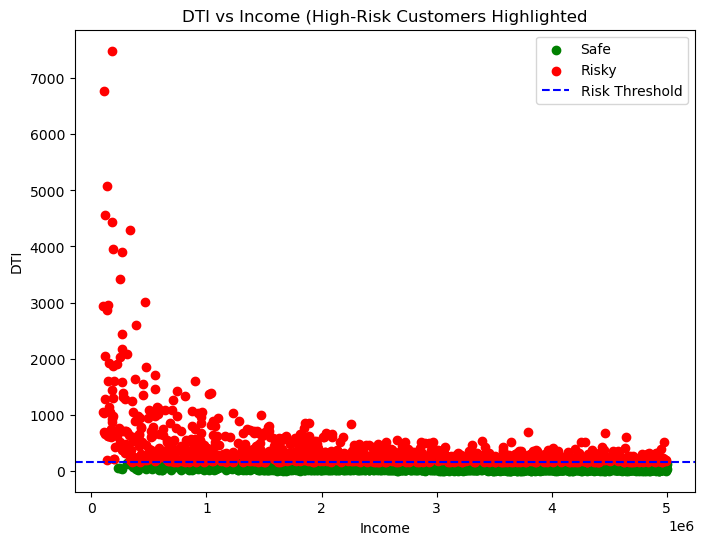

In [25]:
#Unsustainable EMI commitments

def risk_label(DTI):
    if DTI > 150:
        return 'High'
    if DTI > 100:
        return 'Moderate'
    else:
        return 'Safe'


#Applying

dti['Risk_label']=dti['DTI'].apply(risk_label)



#Safe vs Risky

Threshold=150

Safe=dti[dti['DTI'] <= Threshold]
Risky=dti[dti['DTI'] > Threshold]


#scatterplot

plt.figure(figsize=(8,6))
plt.scatter(Safe['Income'],Safe['DTI'],color='g',label='Safe')
plt.scatter(Risky['Income'],Risky['DTI'],color='r',label='Risky')
plt.axhline(y=Threshold,color='b',linestyle='--',label='Risk Threshold')
plt.xlabel('Income')
plt.ylabel('DTI')
plt.title('DTI vs Income (High-Risk Customers Highlighted')
plt.legend()
plt.show()

In [29]:
dti.head(20)

,Customer_ID,Income,Monthly_income,Total_loan_amount,Total_loan_payment,DTI,LTI,Risk_label,Income_bracket
0,CUST1001,4467228,372269.00,1488621,13098.17,3.52,0.33,Safe,4000k-5000k
1,CUST1003,3508627,292385.58,7285879,80427.07,27.51,2.08,Safe,3000k-4000k
2,CUST1004,3740188,311682.33,9482189,305919.05,98.15,2.54,Safe,3000k-4000k
3,CUST1006,1890507,157542.25,12515552,693758.20,440.36,6.62,High,1000k-2000k
4,CUST1007,2911500,242625.00,3623087,42786.32,17.63,1.24,Safe,2000k-3000k
5,CUST1010,1994831,166235.92,5681184,67216.07,40.43,2.85,Safe,1000k-2000k
6,CUST1014,4034524,336210.33,3948873,43650.80,12.98,0.98,Safe,4000k-5000k
7,CUST1017,606396,50533.00,816357,16689.86,33.03,1.35,Safe,<1000k
8,CUST1018,3107710,258975.83,7343904,118361.80,45.70,2.36,Safe,3000k-4000k
9,CUST1020,4788940,399078.33,1811537,81370.24,20.39,0.38,Safe,4000k-5000k


In [12]:
dti['Income'].describe()

count    3.043000e+03
mean     3.055781e+06
std      1.351160e+06
min      1.001560e+05
25%      2.006318e+06
50%      3.251656e+06
75%      4.243509e+06
max      4.999896e+06
Name: Income, dtype: float64

In [39]:
df_s=df_city[['Customer_ID','Branch','City','Loan_Type','risk_segment']]
df_s=df_s.drop_duplicates(subset=['Customer_ID','Branch'])
df_s.head()

,Customer_ID,Branch,City,Loan_Type,risk_segment
0,CUST1001,chennai,Chennai,Home Loan,Low risk
1,CUST1003,kochi,Trivandrum,Auto Loan,Low risk
2,CUST1004,calicut,Bangalore,Personal Loan,Low risk
3,CUST1006,trivandrum,Calicut,Auto Loan,High risk
4,CUST1006,kochi,Calicut,Business Loan,High risk


In [41]:
#credit_score_segmentation
#risk_segment.info()

Total_customers=df_s['Customer_ID'].count()

High_risk_pct = (df_s[df_s['risk_segment'] == 'High risk']['Customer_ID'].count()/Total_customers)*100
low_risk_pct = (df_s[df_s['risk_segment'] == 'Low risk']['Customer_ID'].count()/Total_customers)*100
medium_risk_pct = (df_s[df_s['risk_segment'] == 'Medium risk']['Customer_ID'].count()/Total_customers)*100

print(Total_customers)
print('High risk customers:',High_risk_pct)
print('Low risk customers:',low_risk_pct)
print('Medium risk customers:',medium_risk_pct)

4375
High risk customers: 20.182857142857145
Low risk customers: 78.60571428571428
Medium risk customers: 1.2114285714285715


In [31]:
#Customer risk concentration
#risk_segment.info()

Total_customers=df1['Customer_ID'].count()
customer_risk_concn = {
'High_risk_pct':(df1[df1['Risk_segment'] == 'High Risk']['Customer_ID'].count()/Total_customers)*100,
'low_risk_pct':(df1[df1['Risk_segment'] == 'Low risk']['Customer_ID'].count()/Total_customers)*100,
'medium_risk_pct':(df1[df1['Risk_segment'] == 'Medium risk']['Customer_ID'].count()/Total_customers)*100,
}
print(customer_risk_concn)
#print('High risk customers:',High_risk_pct)
#print('Low risk customers:',low_risk_pct)
#print('Medium risk customers:',medium_risk_pct)

{'High_risk_pct': 47.369646182495345, 'low_risk_pct': 33.7756052141527, 'medium_risk_pct': 18.854748603351958}


In [37]:
#Customer risk concentration (segmentation throuh clustering)
#risk_segment.info()

Total_customers=df1['Customer_ID'].count()
customer_risk_concn = {
'High_risk_pct':(df_clust_H[df_clust_H['Clusters'] == 2]['Customer_ID'].count()/Total_customers)*100,
'low_risk_pct':(df_clust_H[df_clust_H['Clusters'] == 0]['Customer_ID'].count()/Total_customers)*100,
'medium_risk_pct':(df_clust_H[df_clust_H['Clusters'] == 1]['Customer_ID'].count()/Total_customers)*100,
}
print(customer_risk_concn)
#print('High risk customers:',High_risk_pct)
#print('Low risk customers:',low_risk_pct)
#print('Medium risk customers:',medium_risk_pct)

{'High_risk_pct': 12.70949720670391, 'low_risk_pct': 57.21601489757915, 'medium_risk_pct': 0.9078212290502794}


In [43]:
#Customer risk concentration by branch
customer_branch=(df_s.groupby('Branch')['Customer_ID']
                 .count()
                 .reset_index()
                 .rename(columns={'Customer_ID':'Total Customers'})
                )

#print(customer_branch)
customer_risk_branch=(df_s.groupby(['Branch','risk_segment'])['Customer_ID']
                      .count()
                      .reset_index()
                      .rename(columns={'Customer_ID':'Risk_count'})
                     )


risk_pivot = (
    customer_risk_branch
    .pivot(index='Branch',columns='risk_segment',values='Risk_count')
    .reset_index()
)

final_df=risk_pivot.merge(customer_branch, on='Branch',how='left')
final_df['High Risk pct']=(final_df['High risk']/final_df['Total Customers'])*100
print(final_df)
#print('High risk customers:',High_risk_pct)
#print('Low risk customers:',low_risk_pct)
#print('Medium risk customers:',medium_risk_pct)

       Branch  High risk  Low risk  Medium risk  Total Customers  \
0     calicut        217       888           13             1118   
1     chennai        218       836           14             1068   
2       kochi        219       858           11             1088   
3  trivandrum        229       857           15             1101   

   High Risk pct  
0      19.409660  
1      20.411985  
2      20.128676  
3      20.799273  


In [51]:
#Customer risk concentration by branch
customer_branch=(df1.groupby('Branch')['Customer_ID']
                 .count()
                 .reset_index()
                 .rename(columns={'Customer_ID':'Total Customers'})
                )

#print(customer_branch)
customer_risk_branch=(df1.groupby(['Branch','Risk_segment'])['Customer_ID']
                      .count()
                      .reset_index()
                      .rename(columns={'Customer_ID':'Risk_count'})
                     )


risk_pivot = (
    customer_risk_branch
    .pivot(index='Branch',columns='Risk_segment',values='Risk_count')
    .reset_index()
)

final_df=risk_pivot.merge(customer_branch, on='Branch',how='left')
final_df['High Risk pct']=(final_df['High Risk']/final_df['Total Customers'])*100
print(final_df)
#print('High risk customers:',High_risk_pct)
#print('Low risk customers:',low_risk_pct)
#print('Medium risk customers:',medium_risk_pct)

       Branch  High Risk  Low risk  Medium risk  Total Customers  \
0     CALICUT        549       369          203             1121   
1     CHENNAI        513       345          193             1051   
2       KOCHI        481       369          211             1061   
3  TRIVANDRUM        492       368          203             1063   

   High Risk pct  
0      48.974130  
1      48.810657  
2      45.334590  
3      46.284102  


In [97]:
geo_total=df2_city.groupby('City')['Customer_ID'].count()
geo_concn=(df2_city.groupby(['Credit_risk_segment','City'])['Customer_ID']
           .count()
           .reset_index())
geo_high=geo_concn[geo_concn['Credit_risk_segment'] == 'High Risk']
geo_pct=(geo_high['Customer_ID']/geo_total.values)*100
print(geo_pct)
print(geo_concn)
print(geo_total)

0    47.368421
1    47.769314
2    45.621622
3    47.392816
4    48.558247
5    47.729919
Name: Customer_ID, dtype: float64
   Credit_risk_segment        City  Customer_ID
0            High Risk   Bangalore          396
1            High Risk     Calicut          439
2            High Risk     Chennai          422
3            High Risk   Hyderabad          409
4            High Risk       Kochi          421
5            High Risk  Trivandrum          410
6             Low risk   Bangalore          274
7             Low risk     Calicut          311
8             Low risk     Chennai          330
9             Low risk   Hyderabad          288
10            Low risk       Kochi          290
11            Low risk  Trivandrum          300
12         Medium risk   Bangalore          166
13         Medium risk     Calicut          169
14         Medium risk     Chennai          173
15         Medium risk   Hyderabad          166
16         Medium risk       Kochi          156
17         M

In [45]:
geo_total=df_s.groupby('City')['Customer_ID'].count()
geo_concn=(df_s.groupby(['risk_segment','City'])['Customer_ID']
           .count()
           .reset_index())
geo_high=geo_concn[geo_concn['risk_segment'] == 'High risk']
geo_pct=(geo_high['Customer_ID']/geo_total.values)*100
print(geo_pct)
print(geo_concn)
print(geo_total)

0    22.237762
1    22.932331
2    17.453505
3    18.194444
4    18.528610
5    21.438646
Name: Customer_ID, dtype: float64
   risk_segment        City  Customer_ID
0     High risk   Bangalore          159
1     High risk     Calicut          183
2     High risk     Chennai          122
3     High risk   Hyderabad          131
4     High risk       Kochi          136
5     High risk  Trivandrum          152
6      Low risk   Bangalore          548
7      Low risk     Calicut          602
8      Low risk     Chennai          572
9      Low risk   Hyderabad          581
10     Low risk       Kochi          587
11     Low risk  Trivandrum          549
12  Medium risk   Bangalore            8
13  Medium risk     Calicut           13
14  Medium risk     Chennai            5
15  Medium risk   Hyderabad            8
16  Medium risk       Kochi           11
17  Medium risk  Trivandrum            8
City
Bangalore     715
Calicut       798
Chennai       699
Hyderabad     720
Kochi         734
Tr

EMI Commitments of customers and behavoural & characteristics of default customers

In [53]:
df.head()

,Loan_ID,Customer_ID,Loan_Type,Sanction_Amount,Interest_Rate,Tenure_Months,EMI,Loan_Status,Branch,Income,...,LTI,Emi_burden,Interest_burden,Credit_risk,default_flag,PD,cluster_raw,Clusters,Loan_uid,risk_segment
0,LOAN98932,CUST1001,Home Loan,1488621,8.69,240,13098.17,active,chennai,4467228,...,0.33,0.70,2.90,Medium Risk,0,0.115,1,0,1,Low risk
1,LOAN69584,CUST1003,Auto Loan,7285879,12.04,240,80427.07,default,kochi,3508627,...,2.08,5.50,25.00,Low Risk,1,0.045,1,0,2,Low risk
2,LOAN22318,CUST1004,Personal Loan,9482189,9.99,36,305919.05,active,calicut,3740188,...,2.54,2.94,25.33,High Risk,0,0.030,1,0,3,Low risk
3,LOAN42192,CUST1006,Auto Loan,5356368,8.86,180,53882.66,closed,trivandrum,1890507,...,6.62,5.13,25.10,Low Risk,0,0.210,0,2,4,High risk
4,LOAN26694,CUST1006,Business Loan,7159184,13.13,12,639875.54,unknown,kochi,1890507,...,6.62,4.06,49.72,Low Risk,0,0.210,0,2,5,High risk


In [71]:
df_emi = df[['Customer_ID','Income','DTI']]
df_emi = df_emi.drop_duplicates()
emi_risk = df_emi[
    df_emi['DTI']>=50
]
print(1929/3043)
print(3669/5000)
emi_risk.info()
df_emi.info()

0.6339139007558331
0.7338
<class 'pandas.core.frame.DataFrame'>
Index: 1929 entries, 2 to 4993
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer_ID  1929 non-null   object 
 1   Income       1929 non-null   int64  
 2   DTI          1929 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 60.3+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 3043 entries, 0 to 4996
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer_ID  3043 non-null   object 
 1   Income       3043 non-null   int64  
 2   DTI          3043 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 95.1+ KB


In [73]:
default_cust = df[df['Loan_Status'] == 'default']
non_default_cust = df[df['Loan_Status'].isin(['active','closed'])]

In [77]:
summary = default_cust.agg(
    avg_dti = ('DTI','mean'),
    avg_emi_burden = ('Emi_burden','mean'),
    avg_Interest_burden = ('Interest_burden','mean'))
print(summary)
    

                            DTI  Emi_burden  Interest_burden
avg_dti              204.510333         NaN              NaN
avg_emi_burden              NaN    4.208897              NaN
avg_Interest_burden         NaN         NaN        29.291401


In [113]:
summary = non_default_cust.agg(
    avg_dti = ('DTI','mean'),
    avg_emi_burden = ('Emi_burden','mean'),
    avg_Interest_burden = ('Interest_burden','mean'))
print(summary)
    

                            DTI  Emi_burden  Interest_burden
avg_dti              200.055441         NaN              NaN
avg_emi_burden              NaN    4.409588              NaN
avg_Interest_burden         NaN         NaN        31.314926


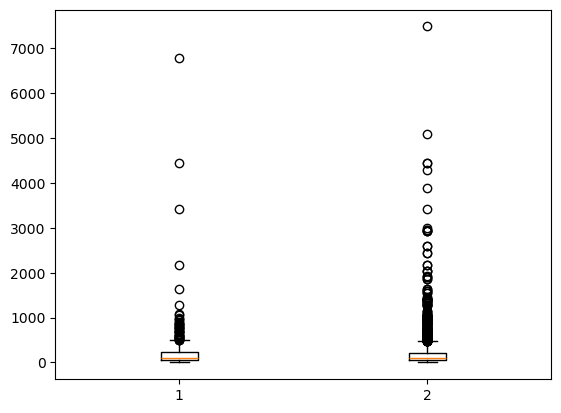

In [121]:
plt.boxplot([default_cust['DTI'],non_default_cust['DTI']])
plt.show()

In [107]:
#outliers
Q1=default_cust['DTI'].quantile(0.25)
Q3=default_cust['DTI'].quantile(0.75)

IQR = Q3-Q1 

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

dti_def = default_cust[(default_cust['DTI'] > lower_bound) & (default_cust['DTI'] < upper_bound)]
dti_def.describe()

,Sanction_Amount,Interest_Rate,Tenure_Months,EMI,Income,Credit_score,Monthly_Income,DTI,LTI,Emi_burden,Interest_burden,default_flag,PD,cluster_raw,Clusters,Loan_uid
count,5.290000e+02,529.000000,529.000000,529.000000,5.290000e+02,529.000000,529.000000,529.000000,529.000000,529.000000,529.000000,529.0,529.000000,529.000000,529.000000,529.000000
mean,4.842215e+06,11.482571,94.706994,159868.560548,3.365573e+06,687.667297,280464.412155,134.101607,3.672987,3.006276,21.163629,1.0,0.094329,0.837429,0.325142,2477.939509
std,2.796951e+06,2.701529,81.493209,171869.953066,1.242684e+06,159.910613,103557.010935,115.814460,3.213945,3.864848,23.012184,0.0,0.082017,0.369323,0.738646,1414.298461
min,1.247420e+05,7.000000,12.000000,1565.370000,3.713600e+05,305.000000,30946.670000,0.420000,0.030000,0.030000,0.250000,1.0,0.025000,0.000000,0.000000,2.000000
25%,2.482460e+06,9.170000,24.000000,50049.760000,2.480463e+06,574.000000,206705.250000,47.620000,1.660000,1.030000,7.490000,1.0,0.035000,1.000000,0.000000,1202.000000
50%,4.818425e+06,11.630000,60.000000,99282.170000,3.644271e+06,714.000000,303689.250000,98.100000,2.990000,2.000000,15.940000,1.0,0.050000,1.000000,0.000000,2489.000000
75%,7.194655e+06,13.860000,180.000000,199453.650000,4.406848e+06,826.000000,367237.330000,188.210000,4.780000,3.620000,25.250000,1.0,0.135000,1.000000,0.000000,3628.000000
max,9.968629e+06,15.980000,240.000000,875478.530000,4.996899e+06,900.000000,416408.250000,504.420000,32.020000,45.660000,258.290000,1.0,0.390000,1.000000,2.000000,4987.000000


In [111]:
#outliers
Q1=non_default_cust['DTI'].quantile(0.25)
Q3=non_default_cust['DTI'].quantile(0.75)

IQR = Q3-Q1 

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

dti_ndef = non_default_cust[(non_default_cust['DTI'] > lower_bound) & (non_default_cust['DTI'] < upper_bound)]
dti_ndef.describe()

,Sanction_Amount,Interest_Rate,Tenure_Months,EMI,Income,Credit_score,Monthly_Income,DTI,LTI,Emi_burden,Interest_burden,default_flag,PD,cluster_raw,Clusters,Loan_uid
count,2.838000e+03,2838.000000,2838.000000,2838.000000,2.838000e+03,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.000000,2838.0,2838.000000,2838.000000,2838.000000,2838.000000
mean,4.975381e+06,11.448034,96.608879,153290.263932,3.337524e+06,673.107118,278127.024098,125.049563,3.644810,3.149891,22.113157,0.0,0.091797,0.843199,0.314658,2500.289641
std,2.804994e+06,2.643898,80.183724,161272.223667,1.208499e+06,164.115028,100708.253662,103.771161,3.067975,4.304300,25.312517,0.0,0.080666,0.364645,0.728108,1445.871993
min,1.001450e+05,7.000000,12.000000,1189.660000,1.318920e+05,300.000000,10991.000000,0.460000,0.030000,0.030000,0.170000,0.0,0.020000,0.000000,0.000000,1.000000
25%,2.542652e+06,9.100000,24.000000,48434.815000,2.481417e+06,549.250000,206784.750000,42.540000,1.640000,1.100000,8.350000,0.0,0.035000,1.000000,0.000000,1260.250000
50%,4.956825e+06,11.460000,60.000000,96154.565000,3.571442e+06,702.000000,297620.125000,95.075000,2.985000,2.110000,16.330000,0.0,0.050000,1.000000,0.000000,2483.500000
75%,7.391337e+06,13.730000,180.000000,198785.580000,4.356473e+06,816.000000,363039.440000,181.775000,4.780000,3.647500,26.550000,0.0,0.125000,1.000000,0.000000,3763.750000
max,9.986611e+06,16.000000,240.000000,888787.130000,4.999896e+06,900.000000,416658.000000,469.830000,45.680000,85.790000,339.990000,0.0,0.420000,2.000000,2.000000,4998.000000


In [109]:
non_default_cust.describe()

,Sanction_Amount,Interest_Rate,Tenure_Months,EMI,Income,Credit_score,Monthly_Income,DTI,LTI,Emi_burden,Interest_burden,default_flag,PD,cluster_raw,Clusters,Loan_uid
count,3.106000e+03,3106.000000,3106.000000,3106.000000,3.106000e+03,3106.000000,3106.000000,3106.000000,3106.000000,3106.000000,3106.000000,3106.0,3106.000000,3106.000000,3106.000000,3106.000000
mean,5.084368e+06,11.453255,94.195750,165924.439250,3.163719e+06,671.853509,263643.282044,200.055441,5.399327,4.409588,31.314926,0.0,0.102824,0.801996,0.433677,2496.798455
std,2.822828e+06,2.643142,80.010082,177060.089479,1.328502e+06,165.177286,110708.484021,358.223503,9.681317,10.128479,61.868129,0.0,0.086995,0.428918,0.816662,1452.469593
min,1.001450e+05,7.000000,12.000000,1189.660000,1.002010e+05,300.000000,8350.080000,0.460000,0.030000,0.030000,0.170000,0.0,0.020000,0.000000,0.000000,1.000000
25%,2.629367e+06,9.092500,24.000000,50650.342500,2.186985e+06,547.000000,182248.750000,46.605000,1.770000,1.180000,8.922500,0.0,0.035000,1.000000,0.000000,1248.750000
50%,5.110058e+06,11.460000,60.000000,100692.960000,3.406934e+06,700.000000,283911.125000,107.015000,3.250000,2.270000,17.470000,0.0,0.060000,1.000000,0.000000,2485.500000
75%,7.569750e+06,13.730000,180.000000,214385.610000,4.307151e+06,816.000000,358929.247500,216.030000,5.600000,4.220000,29.662500,0.0,0.150000,1.000000,0.000000,3756.750000
max,9.986611e+06,16.000000,240.000000,891293.950000,4.999896e+06,900.000000,416658.000000,7490.900000,167.900000,170.520000,937.620000,0.0,0.420000,2.000000,2.000000,4998.000000
